# Study B: same inputs, same accuracy, different reasoning

Reproduces **Study B** of *Right Predictions, Wrong Reasons: Explanation Drift
Monitoring in Production*

In this study the per-feature input PSI is exactly zero by construction and the adversarial score
on raw inputs sits at chance. Accuracy is preserved too. Only the attribution
distributions move.

> Run `01_study_a_covariate_shift.ipynb` first. The final figure needs its
> cached results.

## Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from common import (
    BLUE,
    ERROR_BAR,
    GREY,
    GRID,
    ORANGE,
    RED,
    FIGURES_DIR,
    adv_auc_ci,
    build_constructions,
    fit_baseline,
    fit_variants,
    interval_yerr,
    load_study_a,
    load_study_split,
    numeric_encode,
    raw_psi,
    split_half,
    use_paper_style,
    variant_detail,
    variants_table,
)

use_paper_style()
FIGURES_DIR.mkdir(exist_ok=True)

## 1. One population, scored twice

The same split as Study A, but the older population plays no part here. Every
model version is trained on the same rows and scored on the same rows.

In [2]:
split = load_study_split()
print(f"train {len(split.X_tr):,}   scored {len(split.X_val):,} (identical rows for every version)")

train 24,008   scored 10,290 (identical rows for every version)


## 2. Input monitoring cannot fire here

This is not a small number that might have been large under a different shift.
There is no input difference to detect at all.

In [3]:
print("per-feature raw input PSI, every feature:", raw_psi(split.X_val, split.X_val).abs().max())

encoded_a, encoded_b = split_half(numeric_encode(split.X_val))
raw_split_half = adv_auc_ci(encoded_a, encoded_b)
print(
    f"raw inputs, split-half adversarial AUC: "
    f"{raw_split_half['point']:.3f} [{raw_split_half['lo']:.3f}, {raw_split_half['hi']:.3f}]"
)

per-feature raw input PSI, every feature: 0.0
raw inputs, split-half adversarial AUC: 0.500 [0.490, 0.509]


## 3. Baseline

In [6]:
baseline = fit_baseline(split)
print(f"v1 F1 = {baseline.f1:.4f}")

v1 F1 = 0.7097


## 4. Four version-2 constructions

Reporting a single constructed regression would invite the objection that it is
the one setting where the signal happens to work. So we report a family: a true
null control, an un-engineered change of training configuration, and two
deliberate deprioritisations using LightGBM's per-feature split-gain penalty.

In [7]:
variants = fit_variants(split, baseline, build_constructions(split.feature_order))

  fitted: identical retrain (null control)
  fitted: hyperparameter change
  fitted: `relationship` deprioritised
  fitted: `education-num` dropped


In [8]:
variants_table(variants)

,F1,dF1,agreement,raw input PSI,SHAP AUC,flagged,which
construction,,,,,,,
identical retrain (null control),0.7097,0.0000,100.0%,0.0,--,0,none
hyperparameter change,0.6953,-0.0143,98.2%,0.0,1.0,10,"capital-gain, race, marital-status"
`relationship` deprioritised,0.7089,-0.0008,98.7%,0.0,1.0,3,"relationship, marital-status, sex"
`education-num` dropped,0.7054,-0.0043,98.7%,0.0,1.0,2,"education-num, education"


## 5. The headline case, feature by feature

`relationship` is denied any split gain, so the model falls back on
`marital-status`, which is correlated but genuinely distinct.

In [9]:
headline = variants["`relationship` deprioritised"]
variant_detail(baseline, headline).head(6).round(4)

,mean_abs_v1,mean_abs_v2,rank_v1,rank_v2,psi
relationship,0.5787,0.0000,3,14,20.7233
marital-status,0.7952,1.4142,2,1,3.1396
sex,0.0955,0.0567,10,13,0.9891
education,0.0793,0.0743,12,10,0.1732
capital-loss,0.1207,0.1212,8,7,0.1172
age,0.8215,0.9204,1,2,0.1022


## 6. Plot

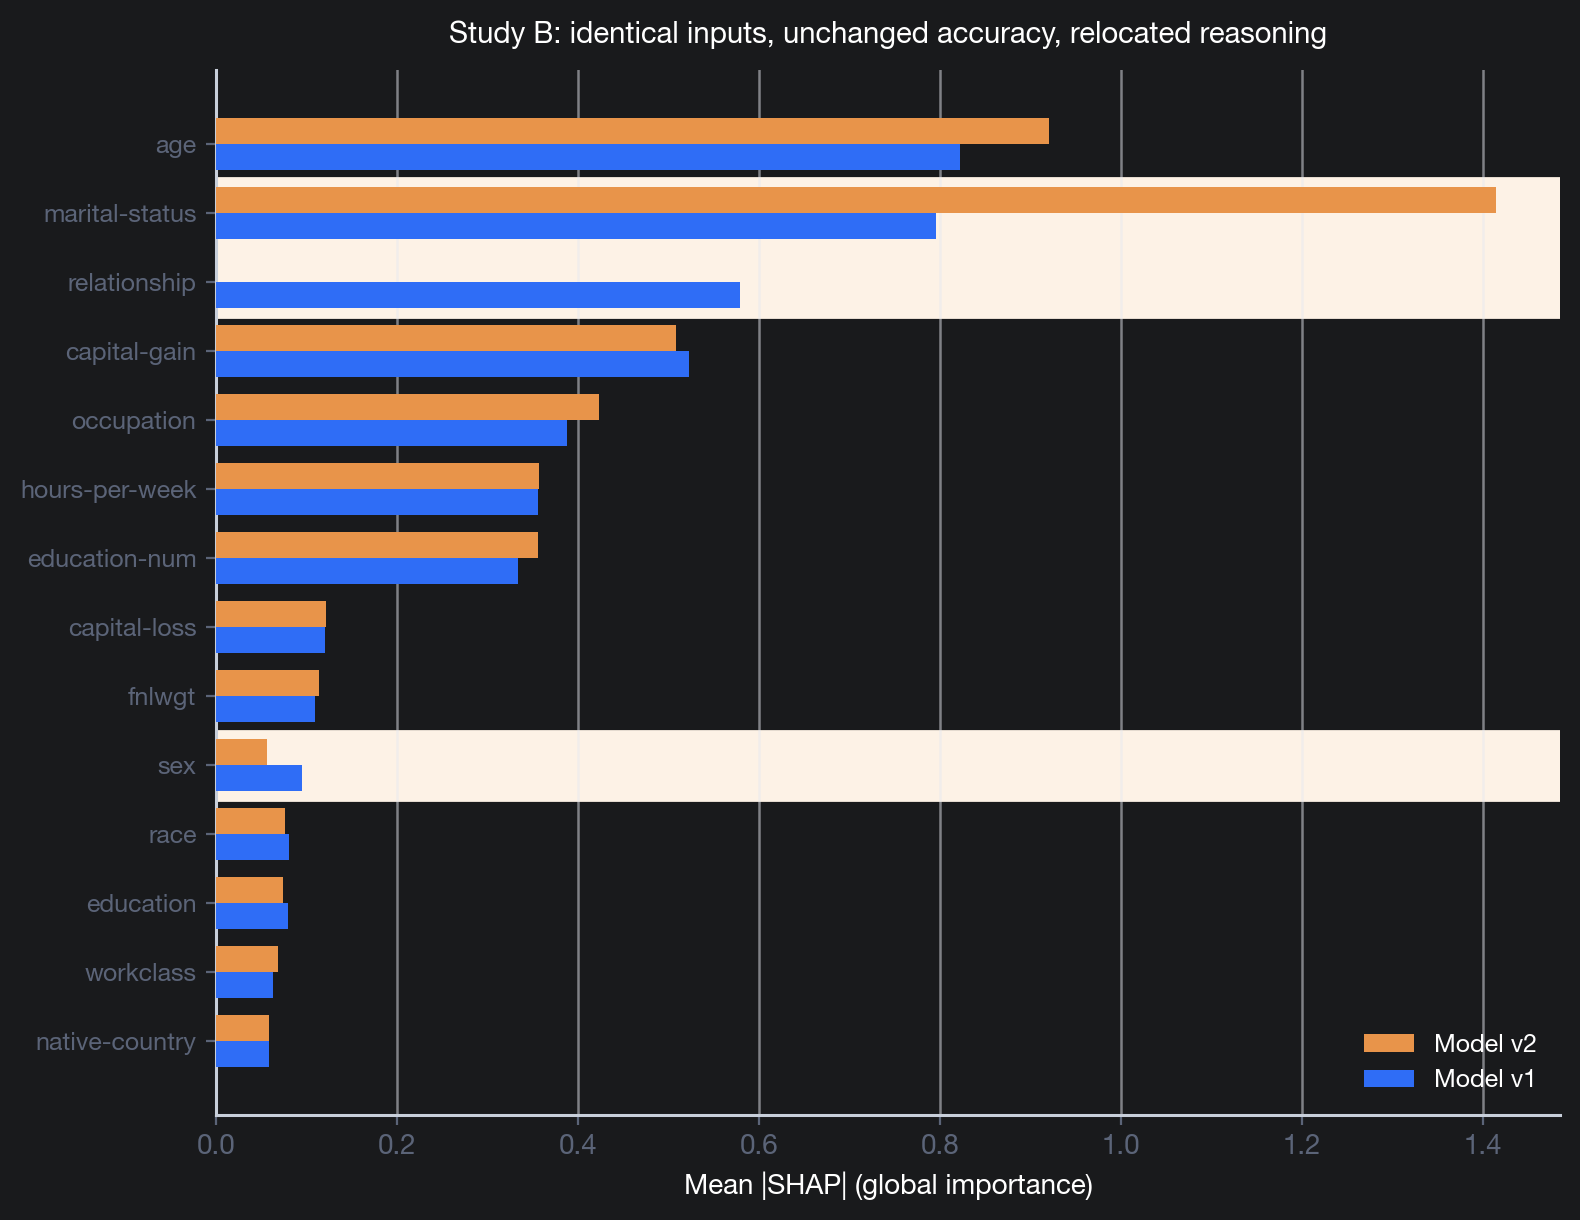

In [10]:
order = baseline.mean_abs.sort_values().index
v1_imp, v2_imp = baseline.mean_abs.reindex(order), headline.mean_abs.reindex(order)
positions, bar_h = np.arange(len(order)), 0.38

fig, ax = plt.subplots(figsize=(8.0, 6.2))
for feature in headline.affected:
    if feature in order:
        row = order.get_loc(feature)
        ax.axhspan(row - 0.5, row + 0.5, color="#fdf2e6", zorder=1)
ax.barh(positions + bar_h / 2, v2_imp, bar_h, color=ORANGE, label="Model v2", zorder=3)
ax.barh(positions - bar_h / 2, v1_imp, bar_h, color=BLUE, label="Model v1", zorder=3)
ax.set_yticks(positions)
ax.set_yticklabels(order, fontsize=9)
ax.set_xlabel("Mean |SHAP| (global importance)")
ax.grid(axis="x", color=GRID, lw=0.9, zorder=0)
ax.legend(fontsize=9, frameon=False, loc="lower right")
ax.set_title(
    "Study B: identical inputs, unchanged accuracy, relocated reasoning", fontsize=10.5, pad=10
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "figure4.png", bbox_inches="tight")
plt.show()

## 7. Plot the two studies side by side

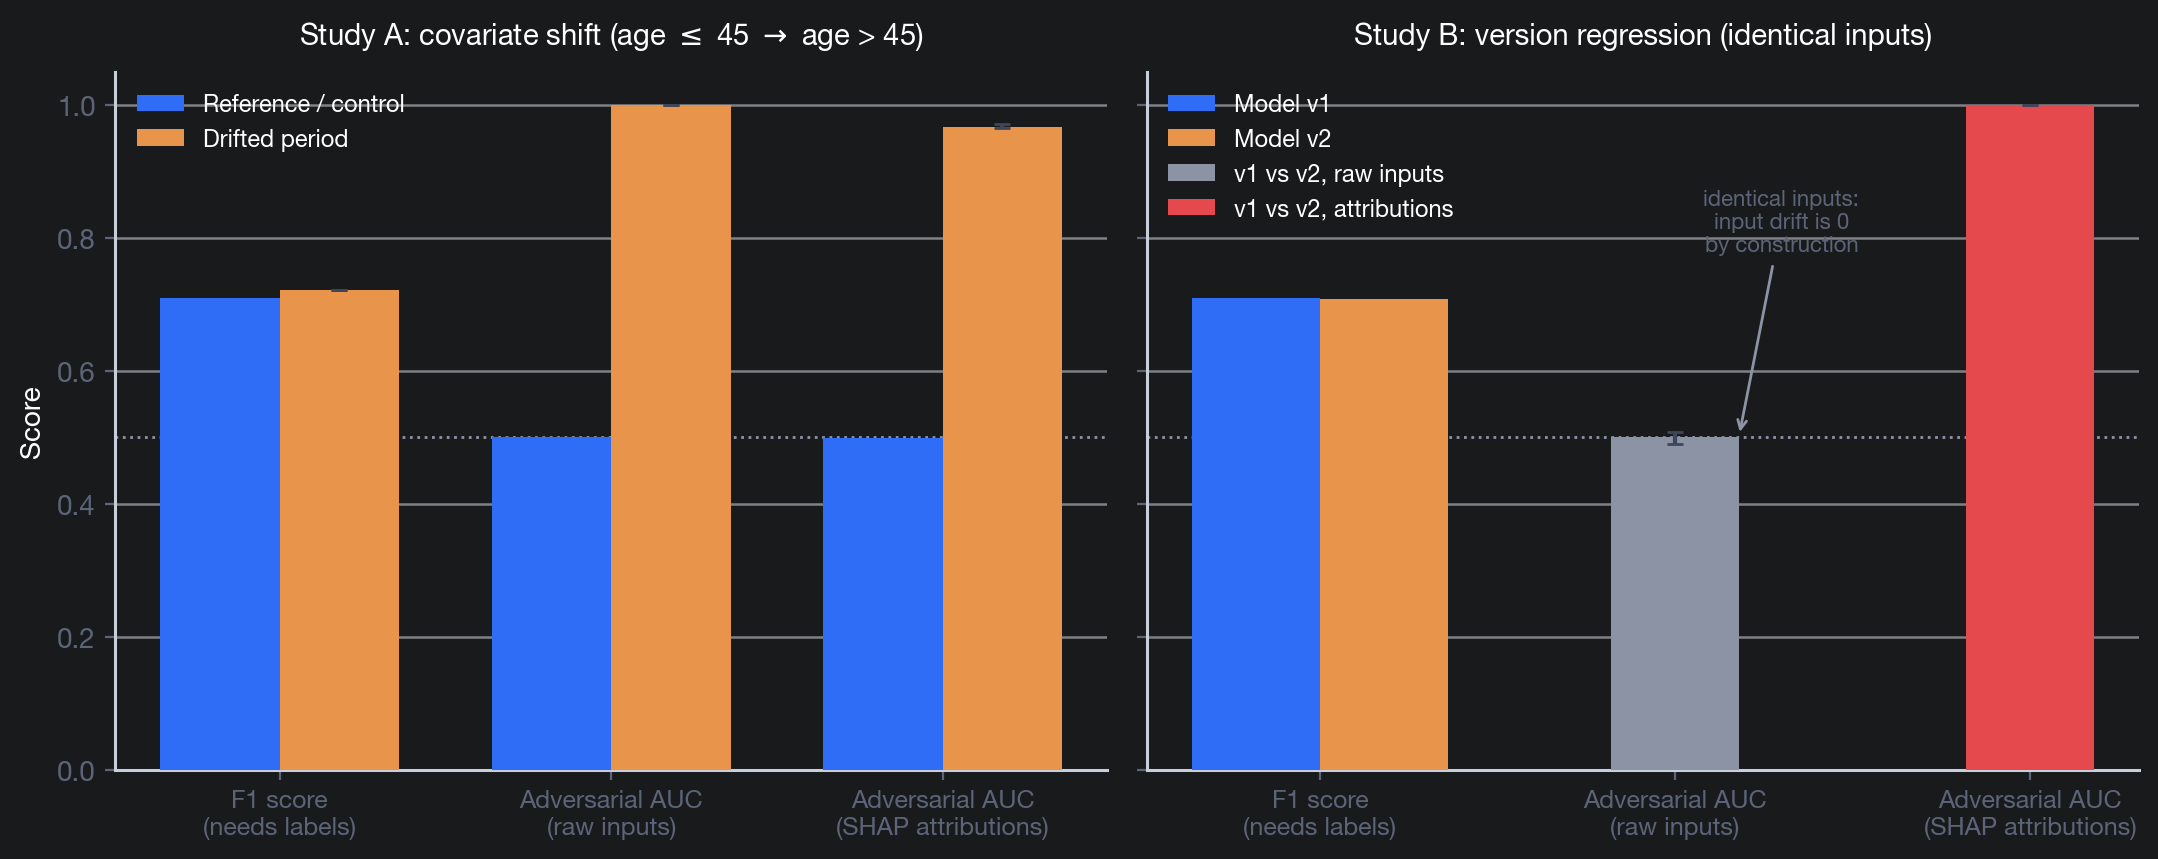

In [11]:
study_a = load_study_a()

labels = [
    "F1 score\n(needs labels)",
    "Adversarial AUC\n(raw inputs)",
    "Adversarial AUC\n(SHAP attributions)",
]
x, bar_w = np.arange(3), 0.36
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.4), sharey=True)

# Left panel: Study A, read back from notebook 01.
a_ref = [
    study_a["f1_ref"],
    study_a["adversarial"]["raw_control"]["point"],
    study_a["adversarial"]["shap_control"]["point"],
]
a_curr = [
    study_a["f1_curr"],
    study_a["adversarial"]["raw_drift"]["point"],
    study_a["adversarial"]["shap_drift"]["point"],
]
a_err = [
    [[0.0], [0.0]],  # F1 is a point estimate, so no interval to draw
    interval_yerr(study_a["adversarial"]["raw_drift"]),
    interval_yerr(study_a["adversarial"]["shap_drift"]),
]
axes[0].bar(x - bar_w / 2, a_ref, bar_w, color=BLUE, label="Reference / control", zorder=3)
for i, (xi, value) in enumerate(zip(x + bar_w / 2, a_curr)):
    axes[0].bar(
        xi,
        value,
        bar_w,
        color=ORANGE,
        zorder=3,
        label="Drifted period" if i == 0 else None,  # one legend entry, not three
        yerr=a_err[i],
        capsize=3,
        ecolor=ERROR_BAR,
    )
axes[0].set_title(
    "Study A: covariate shift (age $\\leq$ 45 $\\to$ age > 45)", fontsize=10.5, pad=10
)

# Right panel: Study B, from this notebook.
axes[1].bar(x[0] - bar_w / 2, baseline.f1, bar_w, color=BLUE, label="Model v1", zorder=3)
axes[1].bar(x[0] + bar_w / 2, headline.f1, bar_w, color=ORANGE, label="Model v2", zorder=3)
axes[1].bar(
    x[1],
    raw_split_half["point"],
    bar_w,
    color=GREY,
    zorder=3,
    yerr=interval_yerr(raw_split_half),
    capsize=3,
    ecolor=ERROR_BAR,
    label="v1 vs v2, raw inputs",
)
axes[1].bar(
    x[2],
    headline.adv["point"],
    bar_w,
    color=RED,
    zorder=3,
    yerr=interval_yerr(headline.adv),
    capsize=3,
    ecolor=ERROR_BAR,
    label="v1 vs v2, attributions",
)
axes[1].set_title("Study B: version regression (identical inputs)", fontsize=10.5, pad=10)
axes[1].annotate(
    "identical inputs:\ninput drift is 0\nby construction",
    xy=(x[1] + 0.18, 0.5),
    xytext=(x[1] + 0.30, 0.78),
    fontsize=8,
    ha="center",
    color="#5b6478",
    arrowprops=dict(arrowstyle="->", color=GREY, lw=1),
)

for ax in axes:
    ax.axhline(0.5, ls=":", lw=1, color=GREY, zorder=1)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.set_yticks(np.arange(0, 1.01, 0.2))
    ax.grid(axis="y", color=GRID, lw=0.9, zorder=0)
    ax.legend(fontsize=8.5, frameon=False, loc="upper left")
axes[0].set_ylabel("Score")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "figure1.png", bbox_inches="tight")
plt.show()